# FER Dataset — General Report

General exploratory analysis of the `fer_data/` folder:
per-class image counts, dimensions, channels, file extensions,
and a sample grid of one image per class.

In [1]:
import os
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("fer_data")
EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

rows = []
for class_dir in sorted(DATA_DIR.iterdir()):
    if not class_dir.is_dir():
        continue
    files = [p for p in class_dir.iterdir() if p.is_file() and p.suffix.lower() in EXTS]
    ext_counts = Counter(p.suffix.lower() for p in files)
    rows.append({
        "class": class_dir.name,
        "n_images": len(files),
        ".jpg": ext_counts.get(".jpg", 0),
        ".jpeg": ext_counts.get(".jpeg", 0),
        ".png": ext_counts.get(".png", 0),
        ".bmp": ext_counts.get(".bmp", 0),
        ".webp": ext_counts.get(".webp", 0),
    })

df = pd.DataFrame(rows)
df["share_%"] = (df["n_images"] / df["n_images"].sum() * 100).round(2)
df

,class,n_images,.jpg,.jpeg,.png,.bmp,.webp,share_%
0,angry😡,152,148,1,3,0,0,12.30
1,fear😟,135,125,1,9,0,0,10.92
2,happy😃,276,273,1,2,0,0,22.33
3,normal🙂,277,275,2,0,0,0,22.41
4,sad😥,221,213,2,6,0,0,17.88
5,surprise😮,175,173,2,0,0,0,14.16


In [2]:
# Sample-based stats: read a small subset per class for shape/channel/mean stats
SAMPLE_PER_CLASS = 25

def class_samples(class_dir, k=SAMPLE_PER_CLASS):
    files = sorted(p for p in class_dir.iterdir()
                   if p.is_file() and p.suffix.lower() in EXTS)
    return files[:k]

stats = []
for class_dir in sorted(DATA_DIR.iterdir()):
    if not class_dir.is_dir():
        continue
    sample_files = class_samples(class_dir)
    shapes, channels, means = [], [], []
    for fp in sample_files:
        img = cv2.imread(str(fp))
        if img is None:
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img_rgb.shape[:2]
        c = 1 if img_rgb.ndim == 2 else img_rgb.shape[2]
        shapes.append((h, w))
        channels.append(c)
        means.append(img_rgb.mean())
    if not shapes:
        continue
    hs = [s[0] for s in shapes]; ws = [s[1] for s in shapes]
    stats.append({
        "class": class_dir.name,
        "sampled": len(sample_files),
        "min_HxW": f"{min(hs)}x{min(ws)}",
        "max_HxW": f"{max(hs)}x{max(ws)}",
        "mean_HxW": f"{int(np.mean(hs))}x{int(np.mean(ws))}",
        "channels_mode": Counter(channels).most_common(1)[0][0],
        "pixel_mean": round(float(np.mean(means)), 2),
    })

pd.DataFrame(stats)

,class,sampled,min_HxW,max_HxW,mean_HxW,channels_mode,pixel_mean
0,angry😡,25,352x260,2932x2932,1022x809,3,120.31
1,fear😟,25,312x220,2160x1582,992x680,3,113.74
2,happy😃,25,441x311,2436x2436,1172x967,3,118.21
3,normal🙂,25,316x248,1696x1696,840x678,3,119.92
4,sad😥,25,188x130,3048x3048,1042x893,3,124.38
5,surprise😮,25,380x252,3048x3048,1113x899,3,116.93


/tmp/ipykernel_205696/1517765785.py:7: UserWarning: Glyph 128578 (\N{SLIGHTLY SMILING FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/lost/XD/AI/fer/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128578 (\N{SLIGHTLY SMILING FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


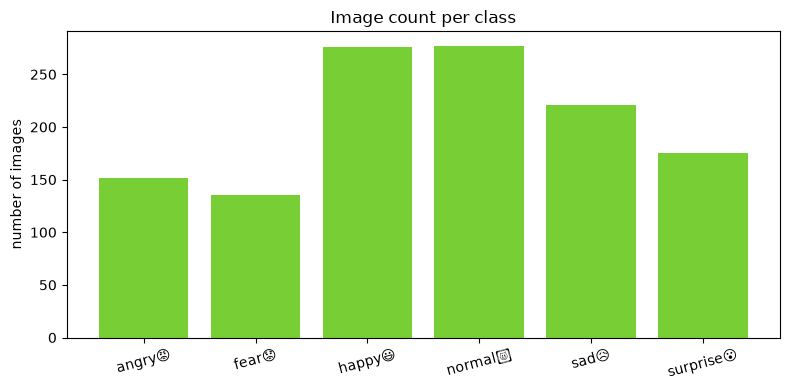

Total images: 1236
Number of classes: 6
Imbalance ratio (max/min): 2.05


In [3]:
# Distribution plot: class counts
plt.figure(figsize=(8, 4))
plt.bar(df["class"], df["n_images"], color="#77CE35")
plt.title("Image count per class")
plt.ylabel("number of images")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print(f"Total images: {df['n_images'].sum()}")
print(f"Number of classes: {len(df)}")
print(f"Imbalance ratio (max/min): "
      f"{df['n_images'].max() / max(df['n_images'].min(), 1):.2f}")

/tmp/ipykernel_205696/2869244981.py:14: UserWarning: Glyph 128578 (\N{SLIGHTLY SMILING FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


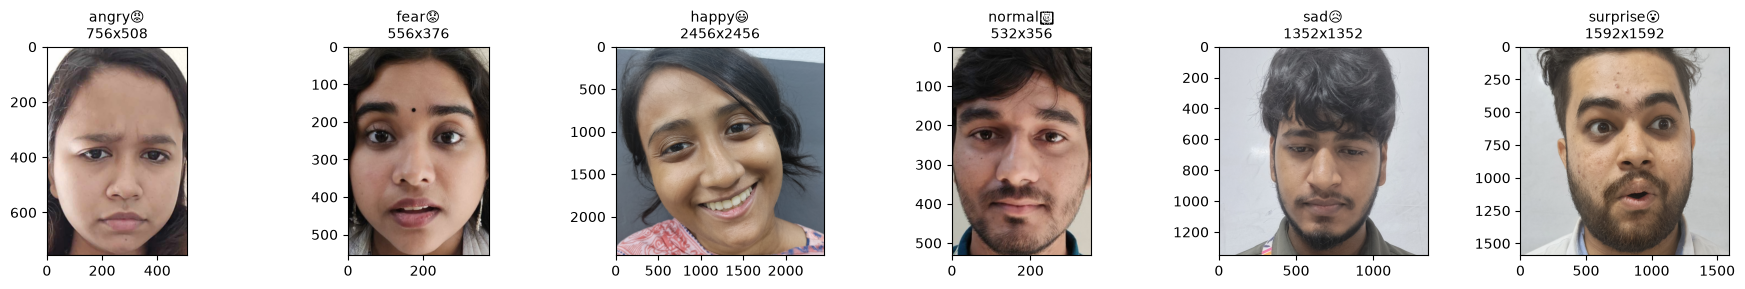

In [4]:
# Sample grid: one image per class
classes = sorted(d for d in DATA_DIR.iterdir() if d.is_dir())
fig, axes = plt.subplots(1, len(classes), figsize=(3 * len(classes), 3))
if len(classes) == 1:
    axes = [axes]
for ax, cls in zip(axes, classes):
    files = sorted(p for p in cls.iterdir()
                   if p.is_file() and p.suffix.lower() in EXTS)
    img = cv2.imread(str(files[34]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"{cls.name}\n{img.shape[0]}x{img.shape[1]}", fontsize=10)
    ax.axis("on")
plt.tight_layout()
plt.show()

# Before vs After: fer_data → fer_data_raw_512

Compares the raw `fer_data/` folder against the processed `fer_data_raw_512/`
folder (produced by `resize.py`). Reports image counts, dimensions, channels,
and pixel-intensity statistics per class so the effect of resizing is visible.

In [5]:
RAW_DIR = Path("fer_data")
NEW_DIR = Path("fer_data_raw_512")
TARGET_SIZE = 512

assert RAW_DIR.exists(), f"Missing folder: {RAW_DIR}"
assert NEW_DIR.exists(), f"Missing folder: {NEW_DIR}"

def class_counts(root: Path):
    out = {}
    for c in sorted(root.iterdir()):
        if not c.is_dir():
            continue
        files = [p for p in c.iterdir() if p.is_file() and p.suffix.lower() in EXTS]
        out[c.name] = len(files)
    return out

raw_counts = class_counts(RAW_DIR)
new_counts = class_counts(NEW_DIR)
classes = sorted(set(raw_counts) | set(new_counts))

cmp_df = pd.DataFrame({
    "class": classes,
    "n_raw":  [raw_counts.get(c, 0) for c in classes],
    "n_512":  [new_counts.get(c, 0) for c in classes],
})
cmp_df["delta"]      = cmp_df["n_512"] - cmp_df["n_raw"]
cmp_df["pct_change"] = ((cmp_df["n_512"] - cmp_df["n_raw"]) /
                        cmp_df["n_raw"].replace(0, pd.NA) * 100).round(2)
cmp_df

,class,n_raw,n_512,delta,pct_change
0,angry😡,152,152,0,0.0
1,fear😟,135,135,0,0.0
2,happy😃,276,276,0,0.0
3,normal🙂,277,277,0,0.0
4,sad😥,221,221,0,0.0
5,surprise😮,175,175,0,0.0


In [6]:
SAMPLE_PER_CLASS = 25

def shape_stats(root: Path, k: int = SAMPLE_PER_CLASS):
    rows = []
    for c in sorted(root.iterdir()):
        if not c.is_dir():
            continue
        files = sorted(p for p in c.iterdir()
                       if p.is_file() and p.suffix.lower() in EXTS)[:k]
        shapes, channels = [], []
        for fp in files:
            img = cv2.imread(str(fp))
            if img is None:
                continue
            h, w = img.shape[:2]
            ch = 1 if img.ndim == 2 else img.shape[2]
            shapes.append((h, w))
            channels.append(ch)
        if not shapes:
            continue
        hs = [s[0] for s in shapes]; ws = [s[1] for s in shapes]
        rows.append({
            "class": c.name,
            "min_HxW":  f"{min(hs)}x{min(ws)}",
            "max_HxW":  f"{max(hs)}x{max(ws)}",
            "mean_HxW": f"{int(np.mean(hs))}x{int(np.mean(ws))}",
            "channels_mode": Counter(channels).most_common(1)[0][0],
            "sampled": len(files),
        })
    return pd.DataFrame(rows)

raw_shape = shape_stats(RAW_DIR).add_prefix("raw_").rename(columns={"raw_class": "class"})
new_shape = shape_stats(NEW_DIR).add_prefix("new_").rename(columns={"new_class": "class"})
dim_cmp = raw_shape.merge(new_shape, on="class", how="outer")
dim_cmp["expected_HxW"] = f"{TARGET_SIZE}x{TARGET_SIZE}"
dim_cmp[[
    "class",
    "raw_min_HxW", "raw_max_HxW", "raw_mean_HxW", "raw_channels_mode",
    "new_min_HxW", "new_max_HxW", "new_mean_HxW", "new_channels_mode",
    "expected_HxW",
]]

,class,raw_min_HxW,raw_max_HxW,raw_mean_HxW,raw_channels_mode,new_min_HxW,new_max_HxW,new_mean_HxW,new_channels_mode,expected_HxW
0,angry😡,352x260,2932x2932,1022x809,3,512x512,512x512,512x512,3,512x512
1,fear😟,312x220,2160x1582,992x680,3,512x512,512x512,512x512,3,512x512
2,happy😃,441x311,2436x2436,1172x967,3,512x512,512x512,512x512,3,512x512
3,normal🙂,316x248,1696x1696,840x678,3,512x512,512x512,512x512,3,512x512
4,sad😥,188x130,3048x3048,1042x893,3,512x512,512x512,512x512,3,512x512
5,surprise😮,380x252,3048x3048,1113x899,3,512x512,512x512,512x512,3,512x512


In [7]:
def intensity_stats(root: Path, k: int = SAMPLE_PER_CLASS):
    rows = []
    for c in sorted(root.iterdir()):
        if not c.is_dir():
            continue
        files = sorted(p for p in c.iterdir()
                       if p.is_file() and p.suffix.lower() in EXTS)[:k]
        means, stds, mins, maxs = [], [], [], []
        dark_share, bright_share = [], []
        for fp in files:
            img = cv2.imread(str(fp))
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            g = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) if img.ndim == 3 else img
            means.append(float(img.mean()))
            stds.append(float(img.std()))
            mins.append(int(img.min()))
            maxs.append(int(img.max()))
            dark_share.append(float((g <  30).mean()))
            bright_share.append(float((g > 225).mean()))
        if not means:
            continue
        rows.append({
            "class": c.name,
            "sampled":  len(files),
            "mean":     round(float(np.mean(means)),  2),
            "std":      round(float(np.mean(stds)),   2),
            "min":      int(min(mins)),
            "max":      int(max(maxs)),
            "dark_%":   round(float(np.mean(dark_share))   * 100, 2),
            "bright_%": round(float(np.mean(bright_share)) * 100, 2),
        })
    return pd.DataFrame(rows)

raw_int = intensity_stats(RAW_DIR).add_prefix("raw_").rename(columns={"raw_class": "class"})
new_int = intensity_stats(NEW_DIR).add_prefix("new_").rename(columns={"new_class": "class"})
int_cmp = raw_int.merge(new_int, on="class", how="outer")
int_cmp["delta_mean"] = (int_cmp["new_mean"] - int_cmp["raw_mean"]).round(2)
int_cmp["delta_std"]  = (int_cmp["new_std"]  - int_cmp["raw_std"]).round(2)
int_cmp[[
    "class",
    "raw_mean", "new_mean", "delta_mean",
    "raw_std",  "new_std",  "delta_std",
    "raw_min",  "new_min",
    "raw_max",  "new_max",
    "raw_dark_%",   "new_dark_%",
    "raw_bright_%", "new_bright_%",
]]

,class,raw_mean,new_mean,delta_mean,raw_std,new_std,delta_std,raw_min,new_min,raw_max,new_max,raw_dark_%,new_dark_%,raw_bright_%,new_bright_%
0,angry😡,120.31,120.32,0.01,57.71,57.66,-0.05,0,0,255,255,6.50,6.46,1.49,1.49
1,fear😟,113.74,113.75,0.01,56.39,56.33,-0.06,0,0,255,255,7.62,7.55,0.43,0.43
2,happy😃,118.21,118.21,0.00,59.08,58.98,-0.10,0,0,255,255,7.09,6.98,2.07,2.06
3,normal🙂,119.92,119.92,0.00,59.72,59.63,-0.09,0,0,255,255,7.19,7.10,0.44,0.44
4,sad😥,124.38,124.39,0.01,59.52,59.43,-0.09,0,0,255,255,6.88,6.75,1.47,1.46
5,surprise😮,116.93,116.94,0.01,56.88,56.80,-0.08,0,0,255,255,6.48,6.41,0.52,0.51


/tmp/ipykernel_205696/2315622090.py:18: UserWarning: Glyph 128578 (\N{SLIGHTLY SMILING FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()


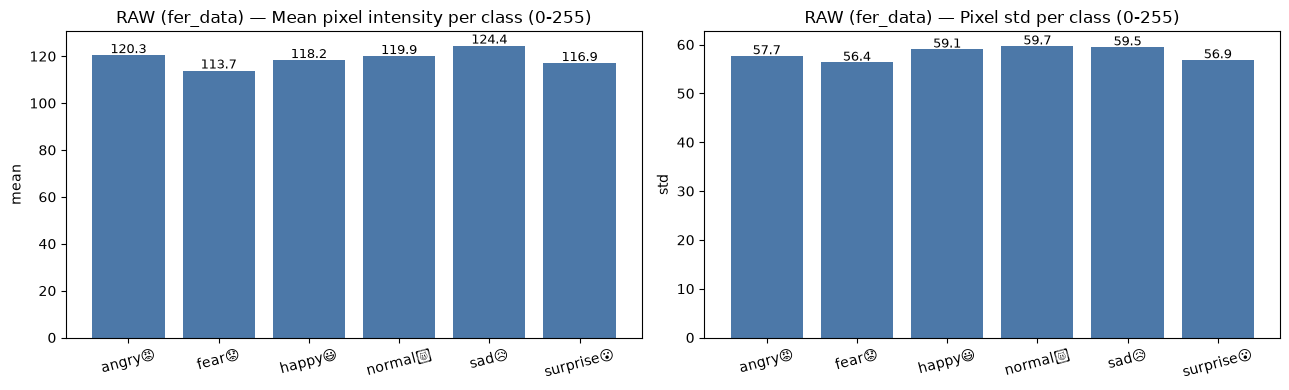

/tmp/ipykernel_205696/2315622090.py:35: UserWarning: Glyph 128578 (\N{SLIGHTLY SMILING FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()


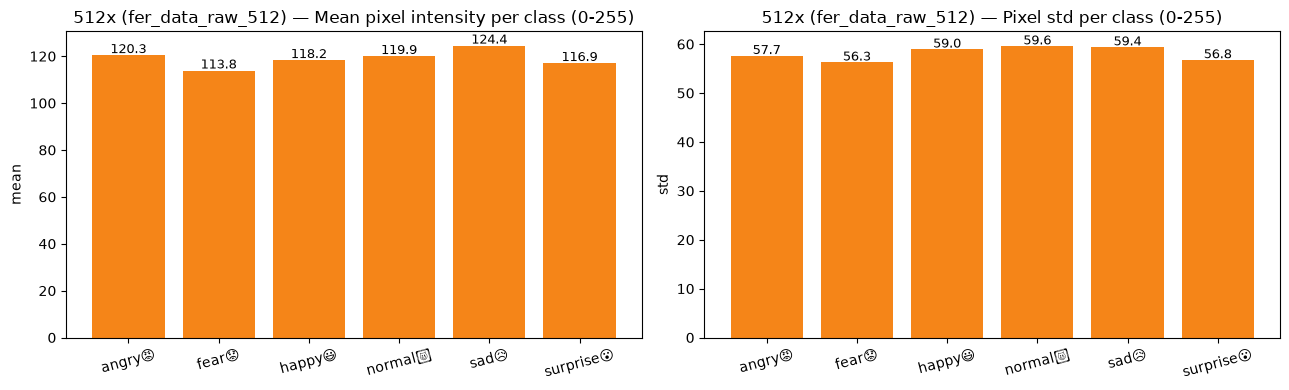

=== Summary: fer_data -> fer_data_raw_512 ===
Total raw images : 1236
Total 512x images: 1236
Net change       : +0
Mean delta mean  : +0.01
Mean delta std   : -0.08


In [10]:
plot_df = int_cmp.set_index("class")[["raw_mean", "new_mean", "raw_std", "new_std"]]

# --- Chart 1: fer_data (raw) ---
fig1, axes1 = plt.subplots(1, 2, figsize=(13, 4))

axes1[0].bar(plot_df.index, plot_df["raw_mean"], color="#4C78A8")
axes1[0].set_title("RAW (fer_data) — Mean pixel intensity per class (0-255)")
axes1[0].set_ylabel("mean"); axes1[0].tick_params(axis="x", rotation=15)
for i, v in enumerate(plot_df["raw_mean"]):
    axes1[0].text(i, v + 1, f"{v:.1f}", ha="center", fontsize=9)

axes1[1].bar(plot_df.index, plot_df["raw_std"], color="#4C78A8")
axes1[1].set_title("RAW (fer_data) — Pixel std per class (0-255)")
axes1[1].set_ylabel("std"); axes1[1].tick_params(axis="x", rotation=15)
for i, v in enumerate(plot_df["raw_std"]):
    axes1[1].text(i, v + 0.3, f"{v:.1f}", ha="center", fontsize=9)

plt.tight_layout(); plt.show()

# --- Chart 2: fer_data_raw_512 (new) ---
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 4))

axes2[0].bar(plot_df.index, plot_df["new_mean"], color="#F58518")
axes2[0].set_title("512x (fer_data_raw_512) — Mean pixel intensity per class (0-255)")
axes2[0].set_ylabel("mean"); axes2[0].tick_params(axis="x", rotation=15)
for i, v in enumerate(plot_df["new_mean"]):
    axes2[0].text(i, v + 1, f"{v:.1f}", ha="center", fontsize=9)

axes2[1].bar(plot_df.index, plot_df["new_std"], color="#F58518")
axes2[1].set_title("512x (fer_data_raw_512) — Pixel std per class (0-255)")
axes2[1].set_ylabel("std"); axes2[1].tick_params(axis="x", rotation=15)
for i, v in enumerate(plot_df["new_std"]):
    axes2[1].text(i, v + 0.3, f"{v:.1f}", ha="center", fontsize=9)

plt.tight_layout(); plt.show()

print("=== Summary: fer_data -> fer_data_raw_512 ===")
print(f"Total raw images : {cmp_df['n_raw'].sum()}")
print(f"Total 512x images: {cmp_df['n_512'].sum()}")
print(f"Net change       : {int(cmp_df['delta'].sum()):+d}")
print(f"Mean delta mean  : {int_cmp['delta_mean'].mean():+.2f}")
print(f"Mean delta std   : {int_cmp['delta_std'].mean():+.2f}")

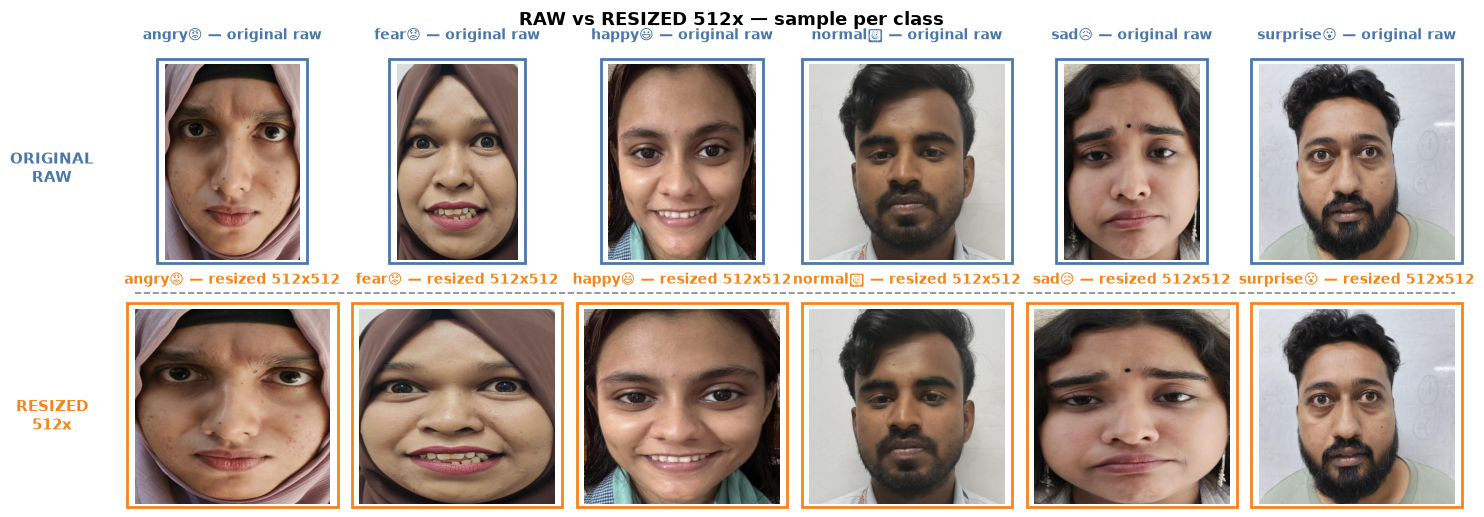

In [28]:
classes = sorted(set(class_counts(RAW_DIR)) & set(class_counts(NEW_DIR)))
fig, axes = plt.subplots(2, len(classes), figsize=(2.5 * len(classes), 5.5))

# Disable tight_layout — we'll manually control spacing
fig.subplots_adjust(left=0.10, right=0.98, top=0.90, bottom=0.10,
                    wspace=0.15, hspace=0.25)

# Row labels on the far left, vertically centered on each row
fig.text(0.045, 0.71, "ORIGINAL\nRAW",
         ha="center", va="center",
         fontsize=11, fontweight="bold", color="#4C78A8")
fig.text(0.045, 0.26, "RESIZED\n512x",
         ha="center", va="center",
         fontsize=11, fontweight="bold", color="#F58518")

for j, cls in enumerate(classes):
    raw_files = sorted(p for p in (RAW_DIR / cls).iterdir()
                       if p.is_file() and p.suffix.lower() in EXTS)
    new_files = sorted(p for p in (NEW_DIR / cls).iterdir()
                       if p.is_file() and p.suffix.lower() in EXTS)
    if not raw_files or not new_files:
        continue
    raw_img = cv2.cvtColor(cv2.imread(str(raw_files[0])), cv2.COLOR_BGR2RGB)
    new_img = cv2.cvtColor(cv2.imread(str(new_files[0])), cv2.COLOR_BGR2RGB)

    axes[0, j].imshow(raw_img)
    axes[0, j].set_title(f"{cls} — original raw\n",
                         fontsize=10, color="#4C78A8", fontweight="bold")

    axes[1, j].imshow(new_img)
    axes[1, j].set_title(f"{cls} — resized 512x512\n",
                         fontsize=10, color="#F58518", fontweight="bold")

    for r in range(2):
        axes[r, j].axis("off")

# Suptitle so it's clearly above all the images
fig.suptitle("RAW vs RESIZED 512x — sample per class \n",
             fontsize=13, fontweight="bold", y=1)

# Color-coded borders around each row (using axes-fraction coords,
# so they sit tightly around the row's axes).
row_specs = [
    (0, "#4C78A8"),  # raw row
    (1, "#F58518"),  # resized row
]

# Horizontal separator between the two rows (figure coords).
# Row labels are at y≈0.71 (raw) and y≈0.26 (resized) → midpoint ≈ 0.485.
sep_y = 0.485
sep_line = plt.Line2D(
    [0.10, 0.98], [sep_y, sep_y],
    transform=fig.transFigure,
    color="#888888", linewidth=1.2, linestyle="--", zorder=11,
)
fig.add_artist(sep_line)

# Small "vs" badge centered on the separator so it reads as a comparison
fig.text(0.5, sep_y, "",
         ha="center", va="center",
         fontsize=10, fontweight="bold", color="#444444",
         bbox=dict(boxstyle="round,pad=0.30",
                   facecolor="white", edgecolor="#888888", linewidth=1),
         zorder=12)

for r, color in row_specs:
    for j in range(len(classes)):
        ax = axes[r, j]
        bbox = ax.get_position()
        # Draw rectangle slightly larger than the axis bounds
        rect = plt.Rectangle(
            (bbox.x0 - 0.005, bbox.y0 - 0.005),
            bbox.width + 0.01, bbox.height + 0.015,
            transform=fig.transFigure,
            fill=False, edgecolor=color, linewidth=2, zorder=10,
        )
        fig.patches.append(rect)

plt.show()